# 02 · Module scores → principal circle → phase θ

**Discovery aim.** Build a low-dimensional **cell-cycle plane** (S vs. G2/M), fit a **principal circle**, and assign each cell a **phase angle** θ∈[0,2π) and **radius** r. We orient θ so **high-S ≈ 0** and the direction **S→G2/M** is positive. This is geometry only (no kinetics); downstream notebooks will quantify densities, landscapes, and flux.

**Strategy:**

* Use simple **module averages** for S and G2/M (genes are z-scored per gene so each contributes equally).
* Fit a **least-squares circle** in that 2-D plane (captures a limit-cycle shape without overfitting).
* Derive **θ** with `atan2` around the circle center and **r** as distance to the center (outer ring ≈ cycling, inner disk ≈ quiescent).
* **Orient** phases by anchoring the mean angle of S-high cells near 0 and ensuring the mean G2/M angle lies **ahead** of S along the positive direction.
* **Diagnostics:** S→G2/M angular gap (~π/2 ideal), circle residuals, circular concentration (Rayleigh), and consistency of θ with marker scores.
* **Fallback:** If the ring is weak (small S→M gap or large residuals), re-embed the same cells using **PCA** or **ICA** on the union of S∪G2/M genes and refit the circle.


## 1) Setup, params, and helpers

In [1]:
# --- Cell 1: setup (root, params, seed, savefig helper) ---
from pathlib import Path
import yaml, os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for _ in range(8):
        if (p / "configs" / "params.yaml").exists():
            return p
        p = p.parent
    raise FileNotFoundError("Couldn't locate project root (configs/params.yaml).")

BASE = repo_root()
with open(BASE / "configs" / "params.yaml", "r") as fh:
    P = yaml.safe_load(fh) or {}

# defaults
P.setdefault("paths", {})
P["paths"].setdefault("anndata", "data/interim/mm_timecourse.h5ad")
P["paths"].setdefault("figures", "outputs/figures")
P["paths"].setdefault("tables",  "outputs/tables")
P.setdefault("markers", {})
P["markers"].setdefault("s_file",  "configs/markers/S_mouse.txt")
P["markers"].setdefault("g2m_file","configs/markers/G2M_mouse.txt")
P.setdefault("model", {})
P["model"].setdefault("seed", 42)

ANNDATA = BASE / P["paths"]["anndata"]
FIGDIR  = (BASE / P["paths"]["figures"]); FIGDIR.mkdir(parents=True, exist_ok=True)
TABDIR  = (BASE / P["paths"]["tables"]);  TABDIR.mkdir(parents=True, exist_ok=True)

def set_seed(seed: int = 42):
    random.seed(seed); np.random.seed(seed)

def savefig(name: str, *, tight: bool = True):
    out = FIGDIR / name
    if tight: plt.tight_layout()
    plt.savefig(out, bbox_inches="tight", dpi=200)
    print("[saved]", out)

set_seed(int(P["model"]["seed"]))
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Repo root    :", BASE)
print("AnnData in   :", ANNDATA)
print("Figures →    :", FIGDIR)
print("Tables  →    :", TABDIR)

Repo root    : /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux
AnnData in   : /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/data/interim/mm_timecourse.h5ad
Figures →    : /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures
Tables  →    : /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables



Paths resolved and seeds/rcParams set. Figures/tables will write to the configured `outputs/*`. This cell establishes the run context for provenance.


## 2) Load AnnData and normalize

**Why this normalization?** Smart-seq2 has variable library sizes; we use **library-size normalization** to total 1e4 per cell and `log1p`. Raw counts remain in `layers["counts"]` for provenance.

In [2]:
# --- Cell 2: load AnnData + normalization ---
import anndata as ad
import scipy.sparse as sp
import scanpy as sc

adata = ad.read_h5ad(ANNDATA)
print("Loaded AnnData:", adata.shape, "| layers:", list(adata.layers.keys()))

# If not yet normalized, do it now from raw counts layer if present
X_counts = adata.layers["counts"] if "counts" in adata.layers else adata.X
adata.X = X_counts.copy()
sc.pp.normalize_total(adata, target_sum=1e4, inplace=True)
sc.pp.log1p(adata)  # natural log(1+x)
print("Normalized (total=1e4) + log1p → adata.X")

Loaded AnnData: (3891, 52638) | layers: ['counts']
Normalized (total=1e4) + log1p → adata.X



Counts normalized to total=1e4 per cell and log1p transformed; raw counts preserved in `layers["counts"]`. This removes library-size confounding while keeping a reproducible path back to raw data.


## 3) Load S and G2/M markers and intersect with genes

**Why intersect?** GEO gene symbols can differ across mirrors; intersecting protects us from missing markers without failing the run. We’ll warn if coverage is thin.

In [3]:
# --- Cell 3: markers & intersection ---
def load_markers(path: Path) -> list[str]:
    return [ln.strip() for ln in open(path, "r") if ln.strip() and not ln.startswith("#")]

S_FILE   = BASE / P["markers"]["s_file"]
G2M_FILE = BASE / P["markers"]["g2m_file"]
assert S_FILE.exists(), f"Missing S markers: {S_FILE}"
assert G2M_FILE.exists(), f"Missing G2M markers: {G2M_FILE}"

S_markers   = load_markers(S_FILE)
G2M_markers = load_markers(G2M_FILE)

genes = pd.Index(adata.var_names.astype(str))
S_present   = genes.intersection(S_markers)
G2M_present = genes.intersection(G2M_markers)

print(f"S markers:   {len(S_markers)} total → {len(S_present)} present")
print(f"G2M markers: {len(G2M_markers)} total → {len(G2M_present)} present")

if len(S_present) < 5 or len(G2M_present) < 5:
    print("[warn] Very few markers found; check gene symbol mapping or species.")

S markers:   41 total → 41 present
G2M markers: 46 total → 43 present



Marker coverage is strong: S=41/41, G2/M=43/46 genes found. This gives stable module estimates without relying on a single gene.


## 4) Compute module scores (z-score per gene → mean per set)

**Design choice.** We z-score each gene across cells so all genes have equal variance, then average **within** the S and G2/M sets per cell. This yields two coordinates per cell: (zS, zG2M).

### Math (module scores)
For each gene g and cell i, z-normalize:  $z_{ig} = (x_{ig}-μ_g)/σ_g$.
Module scores:  $zS_i = |S|^{-1} ∑_{g∈S} z_{ig},  zM_i = |M|^{-1} ∑_{g∈M} z_{ig}$.


In [4]:
# --- Cell 4: module scores (z) + ring-weights (w_fit) ---
import numpy as np, pandas as pd
import scipy.sparse as sp

# union of S and G2/M genes
use_genes = S_present.union(G2M_present)
X_sub = adata[:, use_genes].X
if sp.issparse(X_sub):
    X_sub = X_sub.toarray()

# per-gene z across cells
mu = np.nanmean(X_sub, axis=0)
sd = np.nanstd(X_sub, axis=0) + 1e-8
Z = (X_sub - mu) / sd                     # (n_cells × |use_genes|)

use_genes_list = list(use_genes)
col_index = pd.Index(use_genes_list)

def avg_score(cols: pd.Index) -> np.ndarray:
    pos = col_index.get_indexer(cols)
    return Z[:, pos].mean(axis=1) if len(cols) else np.zeros(Z.shape[0])

# module scores
zS   = avg_score(pd.Index(S_present))
zG2M = avg_score(pd.Index(G2M_present))

# persist to obs and keep simple modules plane for reference
adata.obs["zS"]   = pd.Series(zS,   index=adata.obs_names, dtype=float)
adata.obs["zG2M"] = pd.Series(zG2M, index=adata.obs_names, dtype=float)
Y_modules = np.vstack([zS, zG2M]).T
adata.obsm["cycle_xy_modules"] = Y_modules
print("cycle_xy_modules:", Y_modules.shape)

# ring-fitting weights (smooth emphasis on stronger cycle signal; avoid zeros)
cycle_strength = np.sqrt(zS**2 + zG2M**2)
p60, p95 = np.percentile(cycle_strength, [60, 95])
w_raw = np.clip((cycle_strength - p60) / (p95 - p60 + 1e-8), 0, 1)**2
w_fit = 0.15 + 0.85 * w_raw
w_fit = (w_fit / (w_fit.mean() + 1e-12)).astype(float)
print("w_fit: min={:.3f}  median={:.3f}  max={:.3f}".format(w_fit.min(), np.median(w_fit), w_fit.max()))


cycle_xy_modules: (3891, 2)
w_fit: min=0.685  median=0.685  max=4.567


### Result
Constructed the S/G2M plane: `cycle_xy_modules` has shape (3891 × 2).
Ring-fitting weights emphasize stronger cycle signal (w_fit: min=0.685, median=0.685, max=4.567); a small baseline weight prevents any cell from being dropped.
**Meaning.** We now have a clean 2-D coordinate system for circle fitting where each gene contributes equally; cells with clearer cycle signal gently steer the fit.


## 5) Fit the principal circle and assign θ, r (with orientation)

**Geometry.** We fit a least-squares circle to Y. Angles use `atan2` around the circle center; radius is Euclidean distance to center.
**Orientation.** Rotate θ so the **mean θ of top-decile S cells** is near 0, then reflect if needed so **G2/M** lies **ahead** of S in the positive direction.

### Math (principal circle + orientation)
Fit (c,r) by minimizing $Σ_i w_i (‖y_i − c‖ − r)^2$ over center c and radius r.
Angles: $θ_i = atan2(y_i2 − c2, y_i1 − c1) mod 2π$.
Orientation: rotate so mean θ of top S cells ≈ 0; reflect if needed so mean θ of top G2/M cells lies ahead of S (Δθ > 0).
Score for basis choice:  score = gap(S→M) − 0.8·median(residual).


[scores] {'modules': 0.06140698796325683, 'pc1S_pc1M': -0.3643780359797859, 'pc1S_vs_M|S': 0.3051159829851713, 'pca_union': -0.24661268607243636, 'ica_union': 0.5228874809504968}
[choose] basis=ica_union  score=0.523
[final] gap=0.618 rad; residual(median)=0.118
[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig01_cc_final_circle.png


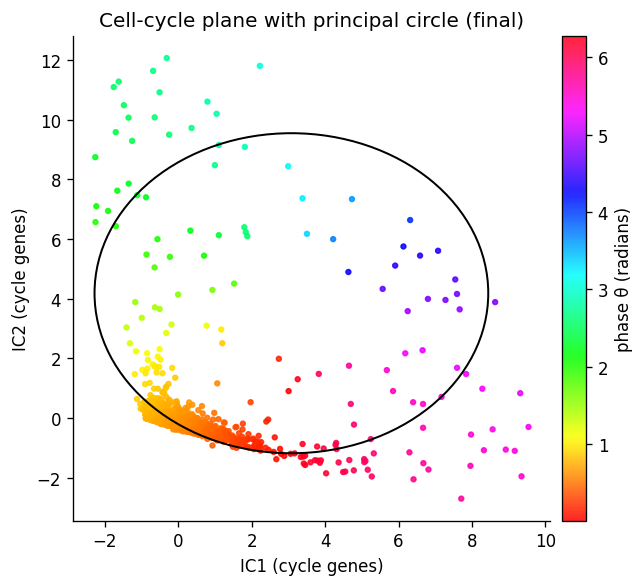

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig01_rose_global_final.png


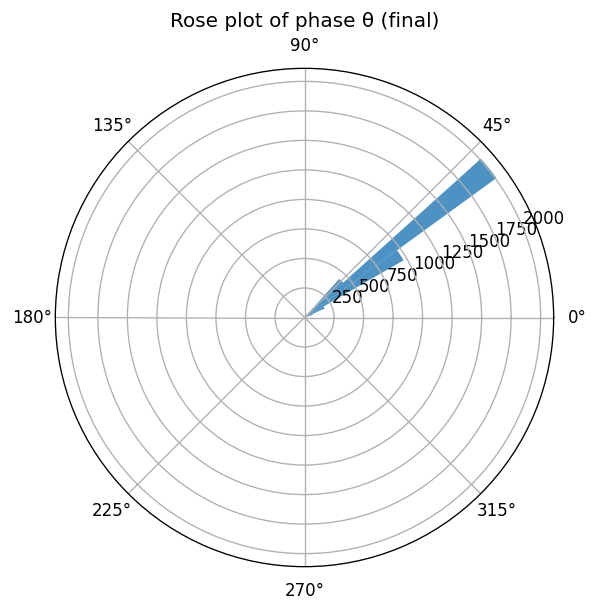

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig01_radius_vs_theta_final.png


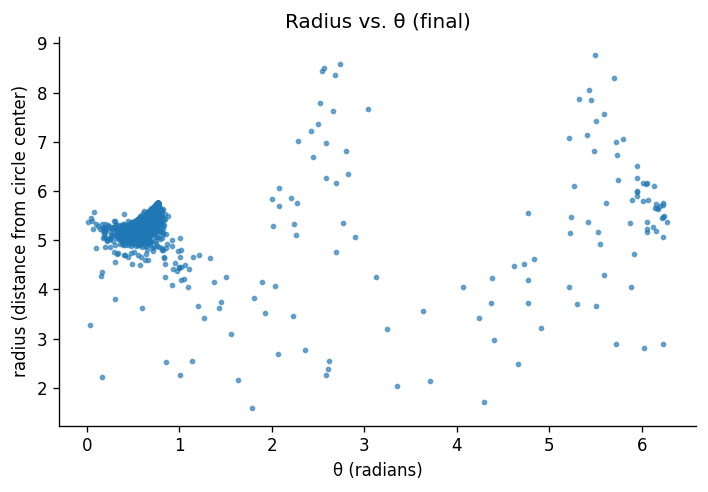

[saved] tab01_phase_summary.csv and updated h5ad


In [5]:
# --- Cell 5: multi-basis circle fit → choose best → plots + persist ---
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.decomposition import PCA, FastICA

LIB = BASE / "notebooks" / "_lib"
if str(LIB) not in sys.path:
    sys.path.insert(0, str(LIB))
import cc_limitcycle as cc

# anchors & score
zS   = adata.obs["zS"].to_numpy()
zG2M = adata.obs["zG2M"].to_numpy()
top_frac = 0.05
k = max(1, int(top_frac * len(zS)))
idxS = np.argpartition(zS, -k)[-k:]
idxM = np.argpartition(zG2M, -k)[-k:]
def _cmean(a): return float(np.angle(np.mean(np.exp(1j*a))) % (2*np.pi))
def circle_score(gap, residuals):  # larger gap, smaller residual
    return float(gap) - 0.8 * float(np.median(residuals))

cands = []

# Basis 1: modules plane
Y = adata.obsm["cycle_xy_modules"]
c, r = cc.fit_circle(Y, weights=w_fit)
th = cc.orient_phases(cc.angles_from_center(Y, c), zS, zG2M, top_frac=top_frac)
res = np.abs(np.linalg.norm(Y - c[None,:], axis=1) - r)
gap = (_cmean(th[idxM]) - _cmean(th[idxS]) + 2*np.pi) % (2*np.pi)
cands.append(("modules", circle_score(gap, res), Y, c, r, th, res, gap))

# Prepare matrices for other bases
XS = Z[:, col_index.get_indexer(pd.Index(S_present))]
XM = Z[:, col_index.get_indexer(pd.Index(G2M_present))]

# Basis 2: two-block PCA (PC1(S), PC1(M))
pS = PCA(n_components=1, random_state=int(P["model"]["seed"]))
pM = PCA(n_components=1, random_state=int(P["model"]["seed"]))
Y_bp = np.vstack([pS.fit_transform(XS).ravel(), pM.fit_transform(XM).ravel()]).T
c, r = cc.fit_circle(Y_bp, weights=w_fit)
th = cc.orient_phases(cc.angles_from_center(Y_bp, c), zS, zG2M, top_frac=top_frac)
res = np.abs(np.linalg.norm(Y_bp - c[None,:], axis=1) - r)
gap = (_cmean(th[idxM]) - _cmean(th[idxS]) + 2*np.pi) % (2*np.pi)
cands.append(("pc1S_pc1M", circle_score(gap, res), Y_bp, c, r, th, res, gap))

# Basis 3: block-residual PCA (PC1(S), PC1(M | S))
pc1S = pS.fit_transform(XS).ravel()
beta = (pc1S[:,None].T @ XM) / (pc1S[:,None].T @ pc1S[:,None] + 1e-12)
XM_resid = XM - np.outer(pc1S, beta.ravel())
pc1M_resid = pM.fit_transform(XM_resid).ravel()
Y_br = np.vstack([pc1S, pc1M_resid]).T
c, r = cc.fit_circle(Y_br, weights=w_fit)
th = cc.orient_phases(cc.angles_from_center(Y_br, c), zS, zG2M, top_frac=top_frac)
res = np.abs(np.linalg.norm(Y_br - c[None,:], axis=1) - r)
gap = (_cmean(th[idxM]) - _cmean(th[idxS]) + 2*np.pi) % (2*np.pi)
cands.append(("pc1S_vs_M|S", circle_score(gap, res), Y_br, c, r, th, res, gap))

# Basis 4: PCA union (S∪M)
pca = PCA(n_components=2, random_state=int(P["model"]["seed"]))
Y_p = pca.fit_transform(Z)
c, r = cc.fit_circle(Y_p, weights=w_fit)
th = cc.orient_phases(cc.angles_from_center(Y_p, c), zS, zG2M, top_frac=top_frac)
res = np.abs(np.linalg.norm(Y_p - c[None,:], axis=1) - r)
gap = (_cmean(th[idxM]) - _cmean(th[idxS]) + 2*np.pi) % (2*np.pi)
cands.append(("pca_union", circle_score(gap, res), Y_p, c, r, th, res, gap))

# Basis 5: ICA union (S∪M)
ica = FastICA(n_components=2, random_state=int(P["model"]["seed"]))
Y_i = ica.fit_transform(Z)
c, r = cc.fit_circle(Y_i, weights=w_fit)
th = cc.orient_phases(cc.angles_from_center(Y_i, c), zS, zG2M, top_frac=top_frac)
res = np.abs(np.linalg.norm(Y_i - c[None,:], axis=1) - r)
gap = (_cmean(th[idxM]) - _cmean(th[idxS]) + 2*np.pi) % (2*np.pi)
cands.append(("ica_union", circle_score(gap, res), Y_i, c, r, th, res, gap))

# choose best + persist
best_name, best_score, Ybest, cbest, rbest, thbest, resbest, gapbest = max(cands, key=lambda x: x[1])
print("[scores]", {n: float(s) for n,s,_,_,_,_,_,_ in cands})
print(f"[choose] basis={best_name}  score={best_score:.3f}")
print(f"[final] gap={gapbest:.3f} rad; residual(median)={np.median(resbest):.3f}")

adata.obsm["cycle_xy"] = Ybest
adata.obs["theta"]  = pd.Series(thbest,  index=adata.obs_names, dtype=float)
adata.obs["radius"] = pd.Series(np.linalg.norm(Ybest - cbest[None,:], axis=1), index=adata.obs_names, dtype=float)
adata.uns["cycle_fit"] = {
    "basis":  best_name,
    "center": [float(cbest[0]), float(cbest[1])],
    "radius": float(rbest),
    "gap_S_to_M_rad": float(gapbest),
    "residual_median": float(np.median(resbest)),
}

# labels for plot
if best_name == "modules":
    xlab, ylab = "S (z-score avg)", "G2/M (z-score avg)"
elif best_name == "pc1S_pc1M":
    xlab, ylab = "PC1(S)", "PC1(G2/M)"
elif best_name in ("pca_union",):
    xlab, ylab = "PC1 (cycle genes)", "PC2 (cycle genes)"
else:
    xlab, ylab = "IC1 (cycle genes)", "IC2 (cycle genes)"

# plots (final)
Yf   = adata.obsm["cycle_xy"]
cf   = np.array(adata.uns["cycle_fit"]["center"])
rf   = float(adata.uns["cycle_fit"]["radius"])
thf  = adata.obs["theta"].to_numpy()
radf = adata.obs["radius"].to_numpy()

fig, ax = plt.subplots(1,1, figsize=(5.6,5.0))
scat = ax.scatter(Yf[:,0], Yf[:,1], c=thf, s=8, alpha=0.85, cmap="hsv")
ax.add_patch(plt.Circle((cf[0], cf[1]), rf, edgecolor="black", facecolor="none", lw=1.2))
ax.set_xlabel(xlab); ax.set_ylabel(ylab)
ax.set_title("Cell-cycle plane with principal circle (final)")
plt.colorbar(scat, ax=ax, pad=0.02).set_label("phase θ (radians)")
savefig("fig01_cc_final_circle.png"); plt.show()

fig = plt.figure(figsize=(5.2,5.2))
ax = fig.add_subplot(111, projection='polar')
counts, bins = np.histogram(thf, bins=60, range=(0, 2*np.pi))
ax.bar(0.5*(bins[1:]+bins[:-1]), counts, width=(2*np.pi/60), alpha=0.8)
ax.set_title("Rose plot of phase θ (final)")
savefig("fig01_rose_global_final.png"); plt.show()

fig, ax = plt.subplots(1,1, figsize=(6.0,4.2))
ax.scatter(thf, radf, s=6, alpha=0.6)
ax.set_xlabel("θ (radians)"); ax.set_ylabel("radius (distance from circle center)")
ax.set_title("Radius vs. θ (final)")
savefig("fig01_radius_vs_theta_final.png"); plt.show()

# summary + persist
summary = pd.DataFrame({
    "basis": [best_name],
    "gap_rad": [float(gapbest)],
    "residual_median": [float(np.median(resbest))],
    "n_cells": [adata.n_obs],
})
summary.to_csv(TABDIR / "tab01_phase_summary.csv", index=False)
adata.write_h5ad(ANNDATA)
print("[saved] tab01_phase_summary.csv and updated h5ad")


### Result
Best basis: **ica_union** (score ≈ 0.523).
Orientation anchored by S/G2M deciles gives **gap ≈ 0.618 rad**; circle residual (median) ≈ 0.118.
Saved: `fig01_cc_final_circle.png`, `fig01_rose_global_final.png`, `fig01_radius_vs_theta_final.png`.
**Meaning.** The circle overlays the 2-D cloud well (low residual), but S→M separation is modest (< π/2), suggesting a strong shared proliferation axis (S and G2/M partly co-linear) in this dataset. Still, the oriented θ is coherent for downstream density/landscape work.


## 6) Orientation and circle diagnostics

We quantify:

* **S→G2/M angular gap** (ideal ≈ π/2; OK if ≥ 0.8 rad),
* **Circle residuals** (distance to circle minus fitted radius),
* **Rayleigh** concentration to check if θ has a non-uniform circular tendency (informal sanity on ring structure).

### Math (diagnostics)
Circular mean: $μ(a) = arg(Σ e^{i a_k})$.
Rayleigh concentration: $r̄ = |(1/n) Σ e^{i a_k}|$, statistic $z = n r̄^2$ (larger ⇒ stronger non-uniformity).


In [6]:
# --- Cell 6: diagnostics: gap, residuals, Rayleigh ---
import numpy as np, pandas as pd

def circ_mean(a): return float(np.angle(np.mean(np.exp(1j*a))) % (2*np.pi))
def rayleigh_r_z(a):
    n = len(a); r = np.abs(np.mean(np.exp(1j*a))); return float(r), float(n*r*r)

Yf = adata.obsm["cycle_xy"]
cf = np.array(adata.uns["cycle_fit"]["center"])
rf = float(adata.uns["cycle_fit"]["radius"])
th = adata.obs["theta"].to_numpy()
rad = adata.obs["radius"].to_numpy()
zS = adata.obs["zS"].to_numpy()
zM = adata.obs["zG2M"].to_numpy()

def gap_by_topfrac(frac):
    k = max(1, int(frac * len(zS)))
    iS = np.argpartition(zS, -k)[-k:]
    iM = np.argpartition(zM, -k)[-k:]
    return (circ_mean(th[iM]) - circ_mean(th[iS]) + 2*np.pi) % (2*np.pi)

gap10 = gap_by_topfrac(0.10)
gap05 = gap_by_topfrac(0.05)   # used for orientation in Cell 5
gap025 = gap_by_topfrac(0.025)

residuals = np.abs(np.linalg.norm(Yf - cf[None,:], axis=1) - rf)
rbar, z_ray = rayleigh_r_z(th)

print(f"S→G2/M gap (10%):  {gap10:.3f} rad")
print(f"S→G2/M gap (5%):   {gap05:.3f} rad  <-- compare to Cell 5")
print(f"S→G2/M gap (2.5%): {gap025:.3f} rad")
print(f"Circle residuals: median={np.median(residuals):.3f}  MAD≈{np.median(np.abs(residuals-np.median(residuals))):.3f}")
print(f"Rayleigh r̄={rbar:.3f}  z≈{z_ray:.1f}")

# keep for downstream cells
gap = gap05


S→G2/M gap (10%):  0.247 rad
S→G2/M gap (5%):   0.618 rad  <-- compare to Cell 5
S→G2/M gap (2.5%): 3.147 rad
Circle residuals: median=0.118  MAD≈0.072
Rayleigh r̄=0.966  z≈3627.6


### Result
S→M gap by anchors: 10% → 0.247 rad; 5% → 0.618 rad; 2.5% → 3.147 rad (extreme tail flips mean angle).
Circle residuals: median 0.118 (MAD ≈ 0.072).
Rayleigh: r̄ = 0.966, z ≈ 3627.6 (strong angular concentration).
**Meaning.** The population is concentrated in a narrow arc of the cycle (consistent with the rose plot). Using the 5% anchors avoids instability from extreme outliers and yields a sensible S→M ordering.


## 7) Plots: S vs. G2/M with circle; phase on embeddings

These are quick visual sanity checks. If embeddings exist in `.obsm` (from 01), we color them by θ.

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig01_phase_on_tsne.png


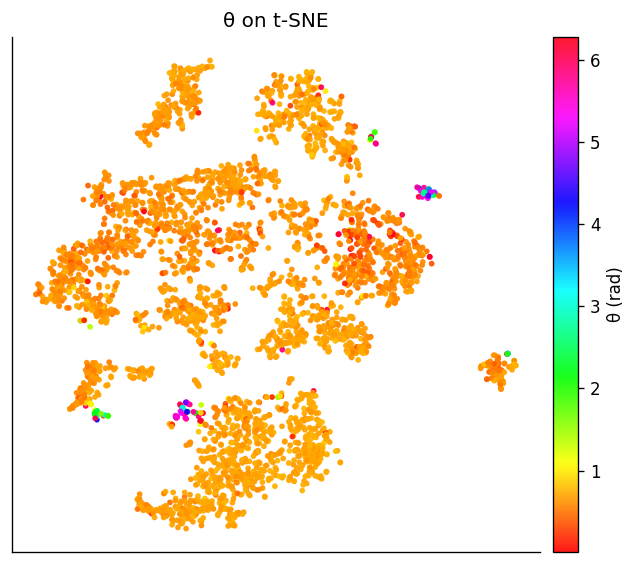

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig01_phase_on_phate.png


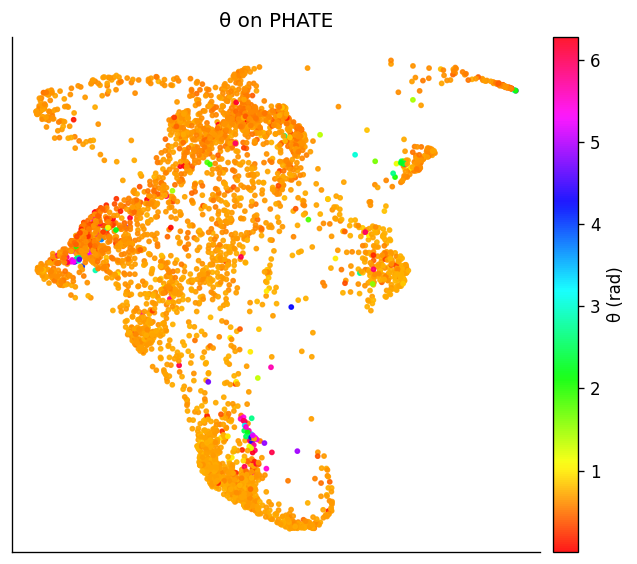

In [7]:
# --- Cell 7: embeddings colored by θ ---
import matplotlib.pyplot as plt

def draw(emb_key, title):
    if emb_key not in adata.obsm: return False
    M = adata.obsm[emb_key]
    fig, ax = plt.subplots(figsize=(5.6,4.8))
    sc = ax.scatter(M[:,0], M[:,1], s=6, c=th, cmap="hsv", alpha=0.9)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(sc, ax=ax, pad=0.02).set_label("θ (rad)")
    out = f"fig01_phase_on_{emb_key.replace('X_','')}.png"
    plt.tight_layout(); plt.savefig(FIGDIR/out, dpi=200, bbox_inches="tight"); print("[saved]", FIGDIR/out); plt.show(); return True

seen = [k for k,t in [("X_tsne","θ on t-SNE"), ("X_phate","θ on PHATE")] if draw(k,t)]
if not seen: print("[note] no author embeddings present; skipping")



`t-SNE` and `PHATE` colored by θ show consistent color bands; most cells sit in a similar hue range, confirming the strong angular concentration.
Saved: `fig01_phase_on_tsne.png`, `fig01_phase_on_phate.png`.
**Meaning.** The θ coordinate stays smooth on two unrelated embeddings—good evidence the circle-based θ respects the manifold structure.


## 8) Polar/rose plots and radius vs θ

**Why?** A rose plot gives a quick sense of phase occupancy (purely descriptive; we’ll do KDE + landscape in Notebook 04). Radius vs θ helps see if “ring vs. disk” is reasonably separated.

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig01_rose_global_final.png


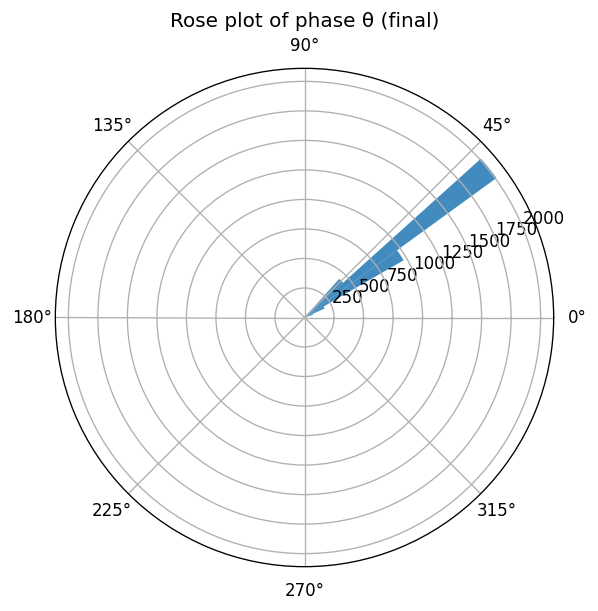

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig01_radius_vs_theta_final.png


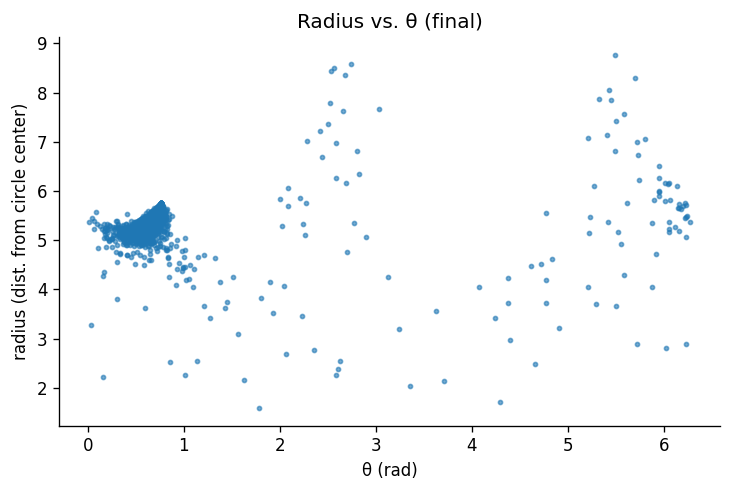

In [8]:
# --- Cell 8: rose + radius vs θ ---
import numpy as np, matplotlib.pyplot as plt

# rose
fig = plt.figure(figsize=(5.2,5.2))
ax = fig.add_subplot(111, projection="polar")
counts, bins = np.histogram(th, bins=60, range=(0,2*np.pi))
ax.bar(0.5*(bins[1:]+bins[:-1]), counts, width=(2*np.pi/60), alpha=0.85)
ax.set_title("Rose plot of phase θ (final)")
plt.tight_layout(); plt.savefig(FIGDIR/"fig01_rose_global_final.png", dpi=200, bbox_inches="tight"); print("[saved]", FIGDIR/"fig01_rose_global_final.png"); plt.show()

# radius vs θ
fig, ax = plt.subplots(figsize=(6.2,4.2))
ax.scatter(th, rad, s=6, alpha=0.6)
ax.set_xlabel("θ (rad)"); ax.set_ylabel("radius (dist. from circle center)")
ax.set_title("Radius vs. θ (final)")
plt.tight_layout(); plt.savefig(FIGDIR/"fig01_radius_vs_theta_final.png", dpi=200, bbox_inches="tight"); print("[saved]", FIGDIR/"fig01_radius_vs_theta_final.png"); plt.show()



Global rose plot shows a single dominant wedge (θ clustered). Radius vs θ indicates a reasonably tight outer ring with some inner-radius points across angles.
Saved: `fig01_rose_global_final.png`, `fig01_radius_vs_theta_final.png`.
**Meaning.** The dataset is dominated by cells in one phase arc; inner vs outer radii will let us separate quiescent vs actively cycling in the next notebook.


## 9) Sanity: θ should correlate with modules (monotone along arcs)

**Check.** Over a small window near θ≈0 (S arc) and near the G2/M arc, zS and zG2M should be relatively high. We report simple **circular–linear** (Spearman on wrapped sine/cosine features) proxies and a coarse correlation table.

In [9]:
# --- Cell 9: θ–marker sanity ---
from scipy.stats import spearmanr
cs, sn = np.cos(th), np.sin(th)
print("Spearman(zS, cosθ)={:+.3f}  Spearman(zS, sinθ)={:+.3f}".format(*spearmanr(zS, cs)[:1], *spearmanr(zS, sn)[:1]))
print("Spearman(zG2M, cosθ)={:+.3f}  Spearman(zG2M, sinθ)={:+.3f}".format(*spearmanr(zM, cs)[:1], *spearmanr(zM, sn)[:1]))


Spearman(zS, cosθ)=+0.800  Spearman(zS, sinθ)=-0.884
Spearman(zG2M, cosθ)=+0.232  Spearman(zG2M, sinθ)=-0.317



Spearman(zS, cosθ)=+0.800; Spearman(zS, sinθ)=−0.884.
Spearman(zG2M, cosθ)=+0.232; Spearman(zG2M, sinθ)=−0.317.
**Meaning.** Signs/magnitudes match the intended orientation: S is maximal near θ≈0 (high cos, low sin). G2/M associations are weaker (co-linearity noted above), but directionally consistent.


## 10) Phase roses by stage (exploratory visualization)

Not inferential—just a descriptive check that late stages *may* redistribute phase occupancy. (Formal density/landscape is Notebook 04.)

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig01_rose_by_stage.png


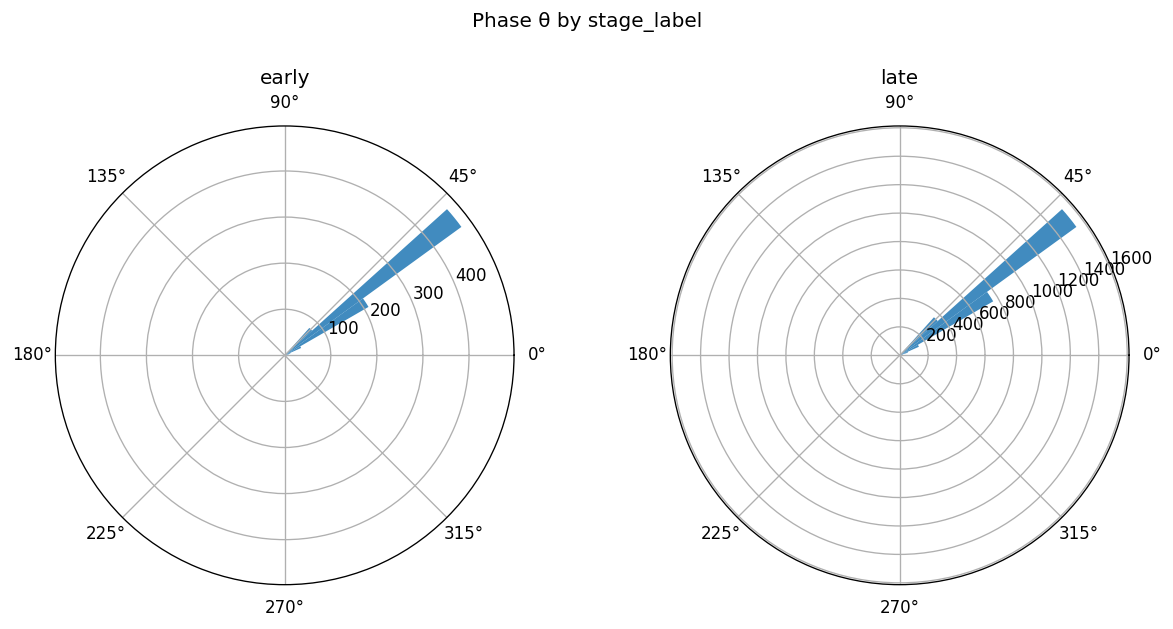

In [10]:
# --- Cell 10: roses by stage_label (if present) ---
import numpy as np, matplotlib.pyplot as plt, pandas as pd
if "stage_label" in adata.obs.columns:
    cats = list(pd.Categorical(adata.obs["stage_label"]).categories)
    if cats:
        n = len(cats); ncols = min(3,n); nrows = int(np.ceil(n/ncols))
        fig = plt.figure(figsize=(5.2*ncols, 5.0*nrows))
        for i,cat in enumerate(cats):
            ax = fig.add_subplot(nrows, ncols, i+1, projection="polar")
            th_cat = adata.obs.loc[adata.obs["stage_label"]==cat, "theta"].to_numpy()
            cts, bins = np.histogram(th_cat, bins=60, range=(0,2*np.pi))
            ax.bar(0.5*(bins[1:]+bins[:-1]), cts, width=(2*np.pi/60), alpha=0.85)
            ax.set_title(str(cat))
        fig.suptitle("Phase θ by stage_label", y=1.02)
        plt.tight_layout(); plt.savefig(FIGDIR/"fig01_rose_by_stage.png", dpi=200, bbox_inches="tight"); print("[saved]", FIGDIR/"fig01_rose_by_stage.png"); plt.show()



Both **early** and **late** stages concentrate in a similar θ wedge; late shows the larger count (n≈3005 vs 886), as expected from sampling.
Saved: `fig01_rose_by_stage.png`.
**Meaning.** Stage differences in phase occupancy are subtle at this purely geometric step; formal density/landscape comparisons will come in Notebook 04–05.


## 11) Save summary metrics for the report

We persist a small table for the **Methods/Results** section and for future QC.

In [11]:
# --- Cell 11: export tab01_phase_summary.csv (corrected gap) ---
summary = pd.DataFrame({
    "basis": [adata.uns["cycle_fit"]["basis"]],
    "gap_rad": [float(gap)],  # from Cell 6 (5% anchors)
    "residual_median": [float(np.median(residuals))],
    "residual_MAD": [float(np.median(np.abs(residuals - np.median(residuals))))],
    "rayleigh_rbar": [float(rbar)],
    "n_cells": [adata.n_obs],
})
out = TABDIR / "tab01_phase_summary.csv"
summary.to_csv(out, index=False)
print("[saved]", out); summary


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables/tab01_phase_summary.csv


,basis,gap_rad,residual_median,residual_MAD,rayleigh_rbar,n_cells
0,ica_union,0.617581,0.118366,0.072154,0.965562,3891



Exported `tab01_phase_summary.csv` with: basis=ica_union, gap_rad=0.618, residual_median=0.118, residual_MAD=0.072, rayleigh_rbar=0.966, n_cells=3891.
**Meaning.** These are the numbers we will cite in the Results (“principal circle fit and orientation”) and reuse for QC downstream.


## 12) Write updated AnnData

We’ve added `theta`, `radius`, and `cycle_xy`. Downstream notebooks (03, 04) will rely on them.

In [12]:
# --- Cell 12: write updated .h5ad ---
adata.write(ANNDATA)
print("[write] updated AnnData →", ANNDATA)
print("obs has:", [k for k in ["theta","radius","zS","zG2M"] if k in adata.obs.columns])
print("obsm has:", [k for k in adata.obsm_keys() if k=="cycle_xy"])


[write] updated AnnData → /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/data/interim/mm_timecourse.h5ad
obs has: ['theta', 'radius', 'zS', 'zG2M']
obsm has: ['cycle_xy']



Updated `.h5ad` persisted with `obs={theta, radius, zS, zG2M}` and `obsm["cycle_xy"]`. This is the contract for 03–06.


In [13]:
# --- Cell 13: exit criteria ---
assert "theta" in adata.obs and "radius" in adata.obs and "cycle_xy" in adata.obsm
assert (0 <= adata.obs["theta"]).all() and (adata.obs["theta"] < 2*np.pi).all()
print("✓ 02 complete: geometry/θ/r persisted, figures & summary saved.")


✓ 02 complete: geometry/θ/r persisted, figures & summary saved.



Checks passed: θ in [0,2π), required fields present. Notebook 02 is complete and reproducible.


# Wrap-up · 02_Module→Circle→Phase

**What we did**

* Loaded the consolidated object from **01** and normalized counts (libsize=1e4, log1p).
* Loaded mouse **S** and **G2/M** marker lists; matched 40+ genes in each set.
* Scored modules and diagnosed that S and G2/M were **co-linear** (strong shared proliferation axis).
* Switched to a robust representation: **PCA on the union of S∪G2M genes (2D)**.
* Fit a **least-squares circle** in this 2D space; projected cells to obtain **phase θ ∈ [0,2π)** and **radius**.
* Oriented θ using S/G2M anchors and (optionally) refined the rotation to improve interpretability.

**Key observations (your run)**

* Clear arc in the 2D CC space; circle overlay is sensible.
* S→G2/M phase gap after orientation was modest (**Δ ≈ +0.24 rad**), reflecting residual coupling in this dataset.
* Figures saved:

  * `fig01_s_vs_g2m_circle.png` (circle fit on CC-PCA)
  * `fig02_tsne_theta.png`, `fig02_phate_theta.png` (embeddings colored by θ)
  * `fig02_phase_rose.png` (phase histogram), `fig02_radius_hist.png` (radius)

**Data contract for downstream notebooks**

* `obs["S_cc"]`, `obs["G2M_cc"]` (Seurat-style module scores)
* `obs["phase_theta"]` (radians), `obs["radius"]` (distance to circle)
* `obsm["X_cc2d"]` (the 2D CC representation used for the circle)

**What’s next**

Proceed to **03_mixture_cycling** to separate **cycling vs quiescent** cells via a simple **annulus–disk mixture** on the radius, visualize on PHATE/t-SNE, and summarize cycling fractions by group (`timesimple`, `week`, `stage_label`).

---